In [ ]:
import numpy as np
import pickle as pkl   
import matplotlib.pyplot as plt
from pymer4.models import Lmer
from utils import plot_adjacency_matrix, plot_level, boxplot, plot_decision_points
import matplotlib.lines as mlines


In [2]:
levels = pkl.load(open('data/LevelsFinal.pkl','rb'))
decision_time_data = pkl.load(open('data/ResultsTime.pkl','rb'))

Linear mixed model for the time standing still on a rock as a function of the rock type

In [4]:
# Modelli per i tempi di decisione
decision_time_data_all = decision_time_data[decision_time_data['PlatformType'] != 'FirstPlatform']

model = Lmer(f"StillTime ~ PlatformType + (1|SubjectID)", data=decision_time_data_all)
result_model = model.fit(factors={'PlatformType': ['Nondecision','Predecision','Decision']})
display(result_model)

random_effects = model.ranef.to_numpy()
random_effects_variance = model.ranef_var['Var']['SubjectID']

# Pairwise comparisons
marginal_estimates, all_decisions_comparisons = model.post_hoc(
    marginal_vars=["PlatformType"], p_adjust="tukey"
)


Linear mixed model fit by REML [’lmerMod’]
Formula: StillTime~PlatformType+(1|SubjectID)

Family: gaussian	 Inference: parametric

Number of observations: 31444	 Groups: {'SubjectID': 40.0}

Log-likelihood: -27123.068 	 AIC: 54256.136

Random effects:

                  Name    Var    Std
SubjectID  (Intercept)  0.216  0.465
Residual                0.326  0.571

No random effect correlations specified

Fixed effects:



c:\Users\david\OneDrive\Desktop\work\projects\Planning-While-Acting\.conda\Lib\site-packages\pymer4\models\Lmer.py:734: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.304,0.159,0.448,0.074,39.040,4.124,0.0,***
PlatformType1,0.049,0.029,0.069,0.010,31402.518,4.748,0.0,***
PlatformType2,0.114,0.098,0.131,0.008,31402.856,13.544,0.0,***


P-values adjusted by tukey method for family of 3 estimates


### Figure 5 - Example of decision/predecision points and effect on the time spent on a rock

[(0, 1, np.float64(0.0)), (0, 2, np.float64(0.0)), (1, 2, np.float64(0.0))]


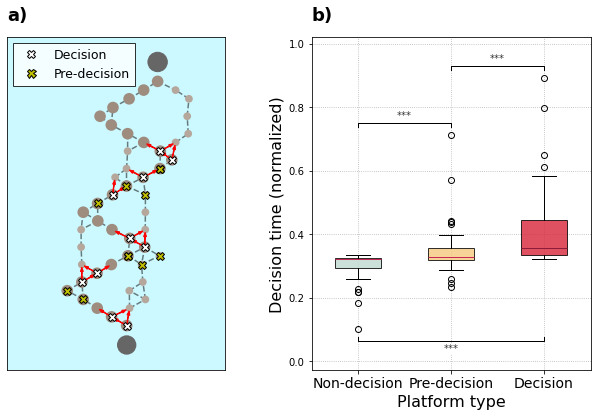

In [12]:
color_blue_pastel = np.array([108, 149, 178])/255
color_bordeaux = np.array([199, 41, 83])/255
color_yellow_sunset = np.array([247, 200, 125])/255
color_red_crimson = np.array([215, 38, 56])/255

fig = plt.figure(figsize=(11,6), dpi=72)
gs = fig.add_gridspec(1,2, width_ratios=(0.5,0.5))

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
axes = [ax1, ax2] 


# Example level, highlighting the decision and pre-decision points
plt.sca(ax1)

level = levels[4]
plot_adjacency_matrix(level, alpha=0.5)
plot_level(level, show_text=False)
plot_decision_points(level, predecision=True)
plt.xlim([-25,20])

decision_marker = mlines.Line2D([], [], linestyle='', color='w', marker='X',
                          markersize=8, markeredgecolor='k', label='Decision')

predecision_marker = mlines.Line2D([], [], linestyle='', color='y', marker='X',
                          markersize=9, markeredgecolor='k', label='Pre-decision')

plt.legend(handles = [decision_marker, predecision_marker], loc='upper left', fontsize=12.5, fancybox=False, edgecolor='k')

# Boxplot for the still time
plt.sca(ax2)

color_1 = color_blue_pastel * 0.6 + np.ones(3) * 0.4 + 0.1 * np.array([1,1,0])
color_2 = color_yellow_sunset
color_3 = color_red_crimson

box_colors = [color_1, color_2, color_3]
median_colors = [color_bordeaux, color_bordeaux, color_bordeaux * 0.7]
xlabels = ['Non-decision','Pre-decision','Decision']

ax = plt.gca()

time_variable = 'StillTime'
time_decision = decision_time_data_all[decision_time_data_all['PlatformType'] == 'Decision']
time_predecision = decision_time_data_all[decision_time_data_all['PlatformType'] == 'Predecision']
time_nondecision = decision_time_data_all[decision_time_data_all['PlatformType'] == 'Nondecision']

times_by_platform_type = np.zeros((40,3))

for i in range(40):
    time_subj = time_nondecision[time_nondecision['SubjectID'] == i][time_variable]
    times_by_platform_type[i,0] = time_subj.mean() - random_effects[i,0]

    time_subj = time_predecision[time_predecision['SubjectID'] == i][time_variable]
    times_by_platform_type[i,1] = time_subj.mean() - random_effects[i,0]

    time_subj = time_decision[time_decision['SubjectID'] == i][time_variable]
    times_by_platform_type[i,2] = time_subj.mean() - random_effects[i,0]

significance_line_position = {(0,1) : 'up', (0,2) : 'down', (1,2) : 'up'}
pvals = all_decisions_comparisons['P-val']
sign_combinations = [(0,1,pvals.iloc[0]),(0,2,pvals.iloc[1]),(1,2,pvals.iloc[2])]
box_colors = box_colors*2
median_colors = median_colors*2

# Plot
boxplot(times_by_platform_type, custom_significant_combinations=sign_combinations, boxes_alpha=0.8, box_colors=box_colors, median_colors=median_colors, significance_lines_position=significance_line_position, sep_multiplier=1, show_connecting_lines=False)

y_lim = plt.ylim()
y_range = (y_lim[1] - y_lim[0])
space = y_range * 0.05
y_lim_new = [y_lim[0] - space, y_lim[1] + space]
plt.ylim(y_lim_new)

plt.xticks([1,2,3], xlabels, fontsize=14)
plt.grid(True, linestyle=':')

plt.xlabel('Platform type', fontsize=16)
plt.ylabel('Decision time (normalized)', fontsize=16)


for i,l in enumerate(['a','b']):
    axes[i].text(0, 1.05, f'{l})', transform=axes[i].transAxes, size=18, weight='bold')

